In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re

# 1. Carga de datos

In [2]:
# Dataset base scrapeado
df = pd.read_csv("dataset/datos_finales.csv")

# Cargamos diccionario de equivalencias de provincias
with open("dataset/provincia_mapping.json", "r", encoding="utf-8") as f:
    prov_map = json.load(f)

# Cargamos fuentes INE como texto para evitar errores de formato numérico
df_paro_raw = pd.read_csv(
    "dataset/datos_paro_actividad_ine.csv",
    sep=";",
    encoding="cp1252",
    dtype=str
)

df_rentas_raw = pd.read_csv(
    "dataset/datos_rentas_ine.csv",
    sep=";",
    encoding="cp1252",
    dtype=str
)

df_turismo_raw = pd.read_csv(
    "dataset/datos_turismo_ine.csv",
    sep=";",
    encoding="utf-8",
    dtype=str
)

df_empresas_raw = pd.read_csv(
    "dataset/datos_num_empresas_ine.csv",
    sep=";",
    encoding="cp1252",
    dtype=str
)

# 2. Data cleaning
## 2.1 Funciones auxiliares

In [3]:
def normalizar_provincia(valor):
    """
    Normaliza nombres de provincia para poder hacer merges entre fuentes.
    - Quita códigos INE al inicio, por ejemplo '03 Alicante/Alacant'
    - Aplica el diccionario de equivalencias prov_map
    """
    if pd.isna(valor):
        return pd.NA
    
    valor = str(valor).strip()
    valor = re.sub(r"^\d+\s+", "", valor)
    
    return prov_map.get(valor, valor)


def limpiar_numero_ine(valor):
    """
    Convierte números del INE con formato español/europeo.
    
    Ejemplos:
    '32.600' -> 32600
    '3.207.580' -> 3207580
    '12,5' -> 12.5
    """
    if pd.isna(valor):
        return pd.NA
    
    valor = str(valor).strip().replace("\xa0", "")
    
    if valor in ["", "..", ".", "nan", "NaN", "None"]:
        return pd.NA
    
    valor = valor.replace(".", "").replace(",", ".")
    
    return pd.to_numeric(valor, errors="coerce")

In [4]:
# Creamos una clave común de provincia en el dataset principal
df["Provincia_key"] = df["Provincia"].apply(normalizar_provincia)

# Comprobación
df[["Provincia", "Provincia_key"]].head()

,Provincia,Provincia_key
0,Albacete,Albacete
1,Alicante,Alicante
2,Almería,Almería
3,Araba/Álava,Araba/Álava
4,Asturias,Asturias


## 2.2 Datos tasa de paro y actividad economica

In [5]:
df_paro = df_paro_raw.copy()

# Nos quedamos con ambos sexos
df_paro = df_paro[df_paro["Sexo"] == "Ambos sexos"].copy()

# Extraemos año
df_paro["Año"] = df_paro["Periodo"].str[:4]

# Filtramos años 2016-2023
df_paro = df_paro[df_paro["Año"].between("2016", "2023")].copy()

# Normalizamos provincia
df_paro["Provincia_key"] = df_paro["Provincias"].apply(normalizar_provincia)

# Creamos nombre de variable
df_paro["Variable"] = (
    df_paro["Tasas"]
    .str.replace("Tasa de ", "", regex=False)
    .str.replace(" de la población", "", regex=False)
    .str.replace(" ", "_", regex=False)
    + "_"
    + df_paro["Año"]
)

# Convertimos Total a numérico
df_paro["Total_num"] = df_paro["Total"].apply(limpiar_numero_ine)

# Pivotamos a formato ancho
df_paro_pivot = (
    df_paro
    .pivot_table(
        index="Provincia_key",
        columns="Variable",
        values="Total_num",
        aggfunc="first"
    )
    .reset_index()
)

# Comprobación
df_paro_pivot.head()

Variable,Provincia_key,actividad_2016,actividad_2017,actividad_2018,actividad_2019,actividad_2020,actividad_2021,actividad_2022,actividad_2023,empleo_2016,...,empleo_2022,empleo_2023,paro_2016,paro_2017,paro_2018,paro_2019,paro_2020,paro_2021,paro_2022,paro_2023
0,Albacete,56.01,59.72,59.13,55.54,58.90,54.60,58.46,57.42,42.96,...,51.96,50.47,23.31,22.01,17.59,16.69,17.44,12.02,11.11,12.09
1,Alicante,58.59,58.43,56.73,59.24,56.99,57.96,59.98,58.64,47.93,...,50.63,50.83,18.21,17.96,15.63,15.68,19.41,18.91,15.57,13.33
2,Almería,61.37,62.55,59.33,60.72,59.73,62.89,62.11,59.17,46.13,...,51.95,50.54,24.84,25.43,18.77,18.53,21.15,15.86,16.36,14.58
3,Araba/Álava,58.85,57.96,58.13,56.40,55.11,58.91,58.57,56.43,51.80,...,53.96,53.47,11.97,9.04,7.39,7.31,9.99,9.48,7.87,5.26
4,Asturias,50.90,50.67,50.27,50.77,50.18,49.75,49.74,50.05,43.48,...,42.69,44.23,14.59,14.64,12.86,13.14,13.50,10.10,14.18,11.62


In [6]:
df = df.merge(df_paro_pivot, on="Provincia_key", how="left")

print("Dimensiones tras merge paro:", df.shape)

cols_paro = [col for col in df.columns if any(x in col for x in ["actividad", "empleo", "paro"])]
sin_paro = df[df[cols_paro].isna().all(axis=1)]["Provincia"].tolist()

print("Provincias sin datos de paro/actividad/empleo:", sin_paro)

Dimensiones tras merge paro: (52, 50)
Provincias sin datos de paro/actividad/empleo: []


## 2.3 Datos ingresos netos medios persona/hogar

In [7]:
df_rentas = df_rentas_raw.copy()

# Convertimos periodo y filtramos 2016-2023
df_rentas["Periodo"] = df_rentas["Periodo"].astype(int)
df_rentas = df_rentas[df_rentas["Periodo"].between(2016, 2023)].copy()

# Normalizamos provincia
df_rentas["Provincia_key"] = df_rentas["Provincias"].apply(normalizar_provincia)

# Convertimos total a numérico correctamente
df_rentas["Total_num"] = df_rentas["Total"].apply(limpiar_numero_ine)

# Renombramos indicadores
mapa_indicadores_renta = {
    "Renta neta media por persona": "Renta_neta_media_persona",
    "Renta neta media por hogar": "Renta_neta_media_hogar"
}

df_rentas["Indicador_limpio"] = df_rentas["Indicadores de renta media"].map(mapa_indicadores_renta)

# Pivotamos a formato ancho
df_rentas_pivot = (
    df_rentas
    .pivot_table(
        index="Provincia_key",
        columns=["Indicador_limpio", "Periodo"],
        values="Total_num",
        aggfunc="first"
    )
)

# Aplanamos columnas
df_rentas_pivot.columns = [
    f"{indicador}_{anio}" 
    for indicador, anio in df_rentas_pivot.columns
]

df_rentas_pivot = df_rentas_pivot.reset_index()

# Comprobación
df_rentas_pivot[
    ["Provincia_key", "Renta_neta_media_hogar_2023", "Renta_neta_media_persona_2023"]
].head()

,Provincia_key,Renta_neta_media_hogar_2023,Renta_neta_media_persona_2023
0,Albacete,32600,13058
1,Alicante,31507,12313
2,Almería,30936,11543
3,Araba/Álava,41914,17806
4,Asturias,35265,15784


In [8]:
df = df.merge(df_rentas_pivot, on="Provincia_key", how="left")

print("Dimensiones tras merge rentas:", df.shape)

cols_renta = [col for col in df.columns if col.startswith("Renta_neta")]
sin_rentas = df[df[cols_renta].isna().all(axis=1)]["Provincia"].tolist()

print("Provincias sin datos de renta:", sin_rentas)

Dimensiones tras merge rentas: (52, 66)
Provincias sin datos de renta: []


## 2.4 Datos Turismo

In [9]:
df_turismo = df_turismo_raw.copy()

# Extraemos año
df_turismo["Periodo"] = df_turismo["Periodo"].str[:4]

# Extraemos provincia quitando los tres primeros caracteres del código INE
df_turismo["Provincia_original"] = df_turismo["Provincias con mayor número de pernoctaciones"].str[3:]

# Normalizamos provincia
df_turismo["Provincia_key"] = df_turismo["Provincia_original"].apply(normalizar_provincia)

# Nos quedamos con el periodo 2016-2023 y solo viajeros
df_turismo = df_turismo[
    (df_turismo["Periodo"].between("2016", "2023")) &
    (df_turismo["Viajeros y pernoctaciones"] == "Viajero")
].copy()

# Convertimos Total a numérico
df_turismo["Total_num"] = df_turismo["Total"].apply(limpiar_numero_ine)

# Agrupamos por provincia, residencia y año
df_turismo_group = (
    df_turismo
    .groupby(["Provincia_key", "Residencia", "Periodo"], as_index=False)["Total_num"]
    .sum()
)

# Creamos nombre de variable
df_turismo_group["Variable"] = (
    df_turismo_group["Residencia"]
    .str.replace("en ", "", regex=False)
    .str.replace(" el", "", regex=False)
    .str.replace(" ", "_", regex=False)
    + "_"
    + df_turismo_group["Periodo"].astype(str)
)

# Pivotamos
df_turismo_pivot = (
    df_turismo_group
    .pivot_table(
        index="Provincia_key",
        columns="Variable",
        values="Total_num",
        aggfunc="sum"
    )
    .reset_index()
)

# Comprobación
df_turismo_pivot.head()

Variable,Provincia_key,Residentes_España_2016,Residentes_España_2017,Residentes_España_2018,Residentes_España_2019,Residentes_España_2020,Residentes_España_2021,Residentes_España_2022,Residentes_España_2023,Residentes_Extranjero_2016,Residentes_Extranjero_2017,Residentes_Extranjero_2018,Residentes_Extranjero_2019,Residentes_Extranjero_2020,Residentes_Extranjero_2021,Residentes_Extranjero_2022,Residentes_Extranjero_2023
0,Albacete,63749,70255,72286,75461,41093,62895,83629,97485,477,452,1636,1442,195,234,926,821
1,Alicante,27857,35255,39689,49300,31758,30875,36578,47576,4922,9064,9121,10328,3630,3611,7649,12983
2,Almería,12344,15729,12463,13802,8121,14694,19423,20876,5188,8012,6871,6715,1235,3716,4957,8812
3,Araba/Álava,27955,28411,24926,26607,11638,25310,29264,30270,4748,4089,4870,3811,397,1225,3808,7214
4,Asturias,209459,253794,254661,274704,183816,233239,244450,259414,19399,29091,32032,28840,5976,12917,23167,39599


In [10]:
df = df.merge(df_turismo_pivot, on="Provincia_key", how="left")

print("Dimensiones tras merge turismo:", df.shape)

cols_turismo = [
    col for col in df.columns 
    if col.startswith("residentes") or col.startswith("Residentes")
]

sin_turismo = df[df[cols_turismo].isna().all(axis=1)]["Provincia"].tolist()

print("Provincias sin datos de turismo:", sin_turismo)

Dimensiones tras merge turismo: (52, 82)
Provincias sin datos de turismo: ['Ceuta', 'Melilla']


En las variables de turismo se detectan valores faltantes para Ceuta y Melilla. Estos valores no proceden de un error de integración, sino de la ausencia de registros para estas ciudades autónomas en la fuente turística utilizada. Por este motivo, se mantienen como valores faltantes en el dataset integrado y se imputan posteriormente en el dataset de modelado mediante la mediana de la variable correspondiente.

## 2.5 Datos Num. empresas

In [11]:
df_empresas = df_empresas_raw.copy()

# Filtramos registros válidos
df_empresas = df_empresas[
    (df_empresas["Provincias"] != "Total Nacional") &
    (df_empresas["Condición jurídica"] == "Total")
].copy()

# Convertimos periodo y filtramos 2016-2023
df_empresas["Periodo"] = df_empresas["Periodo"].astype(int)
df_empresas = df_empresas[df_empresas["Periodo"].between(2016, 2023)].copy()

# Normalizamos provincia
df_empresas["Provincia_key"] = df_empresas["Provincias"].apply(normalizar_provincia)

# Convertimos Total a numérico
df_empresas["Total_num"] = df_empresas["Total"].apply(limpiar_numero_ine)

# Pivotamos
df_empresas_pivot = (
    df_empresas
    .pivot_table(
        index="Provincia_key",
        columns="Periodo",
        values="Total_num",
        aggfunc="first"
    )
)

df_empresas_pivot.columns = [
    f"Num_empresas_{anio}" 
    for anio in df_empresas_pivot.columns
]

df_empresas_pivot = df_empresas_pivot.reset_index()

# Comprobación
df_empresas_pivot.head()

,Provincia_key,Num_empresas_2016,Num_empresas_2017,Num_empresas_2018,Num_empresas_2019,Num_empresas_2020,Num_empresas_2021,Num_empresas_2022,Num_empresas_2023
0,Albacete,26884,26921,26743,26275,26350,26221,26473,24852
1,Alicante,133124,135480,138964,142933,145431,144573,147286,136754
2,Almería,41212,42329,42931,43406,44092,44437,45281,42724
3,Araba/Álava,20034,18518,19147,18678,18851,18628,18771,17629
4,Asturias,67675,68368,68688,68661,68433,67573,68068,64611


In [12]:
df = df.merge(df_empresas_pivot, on="Provincia_key", how="left")

print("Dimensiones tras merge empresas:", df.shape)

cols_empresas = [col for col in df.columns if col.startswith("Num_empresas")]
sin_empresas = df[df[cols_empresas].isna().all(axis=1)]["Provincia"].tolist()

print("Provincias sin datos de empresas:", sin_empresas)

Dimensiones tras merge empresas: (52, 90)
Provincias sin datos de empresas: []


## 2.6 Reducción de dimensionalidad temporal

Tras integrar las distintas fuentes, el dataset contiene varias variables medidas año a año entre 2016 y 2023. Para reducir la dimensionalidad y facilitar el análisis posterior, se crean variables agregadas mediante la media del periodo para los principales indicadores: tasas laborales, renta, número de empresas y turismo.

Estas variables resumen el comportamiento estructural de cada provincia durante el periodo analizado y evitan introducir demasiadas columnas temporales en los modelos posteriores.

In [13]:
# Convertimos explícitamente a numéricas las columnas creadas desde fuentes INE

prefijos_numericos = [
    "actividad_",
    "empleo_",
    "paro_",
    "Renta_neta_media_persona_",
    "Renta_neta_media_hogar_",
    "Residentes_España_",
    "Residentes_Extranjero_",
    "Num_empresas_"
]

cols_integradas_numericas = [
    col for col in df.columns
    if any(col.startswith(prefijo) for prefijo in prefijos_numericos)
]

for col in cols_integradas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# Columnas temporales 2016-2023
activity_cols = [f"actividad_{y}" for y in range(2016, 2024)]
employment_cols = [f"empleo_{y}" for y in range(2016, 2024)]
unemployment_cols = [f"paro_{y}" for y in range(2016, 2024)]

income_person_cols = [f"Renta_neta_media_persona_{y}" for y in range(2016, 2024)]
income_house_cols = [f"Renta_neta_media_hogar_{y}" for y in range(2016, 2024)]

company_cols = [f"Num_empresas_{y}" for y in range(2016, 2024)]

res_es_cols = [f"Residentes_España_{y}" for y in range(2016, 2024)]
res_ext_cols = [f"Residentes_Extranjero_{y}" for y in range(2016, 2024)]


# Variables agregadas
df["actividad_media_2016_2023"] = df[activity_cols].mean(axis=1)
df["empleo_media_2016_2023"] = df[employment_cols].mean(axis=1)
df["paro_media_2016_2023"] = df[unemployment_cols].mean(axis=1)

df["Renta_neta_media_persona_2016_2023"] = df[income_person_cols].mean(axis=1)
df["Renta_neta_media_hogar_2016_2023"] = df[income_house_cols].mean(axis=1)

df["Num_empresas_media_2016_2023"] = df[company_cols].mean(axis=1)

df["Residentes_España_media_2016_2023"] = df[res_es_cols].mean(axis=1)
df["Residentes_Extranjero_media_2016_2023"] = df[res_ext_cols].mean(axis=1)


# Comprobación
df[
    [
        "Provincia",
        "actividad_media_2016_2023",
        "empleo_media_2016_2023",
        "paro_media_2016_2023",
        "Renta_neta_media_persona_2016_2023",
        "Renta_neta_media_hogar_2016_2023",
        "Num_empresas_media_2016_2023",
        "Residentes_España_media_2016_2023",
        "Residentes_Extranjero_media_2016_2023"
    ]
].head()

,Provincia,actividad_media_2016_2023,empleo_media_2016_2023,paro_media_2016_2023,Renta_neta_media_persona_2016_2023,Renta_neta_media_hogar_2016_2023,Num_empresas_media_2016_2023,Residentes_España_media_2016_2023,Residentes_Extranjero_media_2016_2023
0,Albacete,57.47250,47.95375,16.53250,11083.000,28296.625,26339.875,70856.625,772.875
1,Alicante,58.32000,48.50750,16.83750,10342.125,26607.125,140568.125,37361.000,7663.500
2,Almería,60.98375,49.11750,19.44000,9655.500,26164.375,43301.500,14681.500,5688.250
3,Araba/Álava,57.54500,52.62250,8.53875,16177.500,38114.500,18782.000,25547.625,3770.250
4,Asturias,50.29125,43.71125,13.07875,13651.500,31049.000,67759.625,239192.125,23877.625


## 2.7 Comprobaciones de calidad del dataset integrado

In [14]:
print("Dimensiones finales:", df.shape)

# Provincias duplicadas
print("Provincias duplicadas:", df["Provincia"].duplicated().sum())

# Nulos por columna
df.isna().sum().sort_values(ascending=False).head(30)

Dimensiones finales: (52, 98)
Provincias duplicadas: 0


Sede (ciudad)                            21
Presupuesto (€)                           3
Residentes_España_2019                    2
Residentes_Extranjero_2019                2
Renta_neta_media_hogar_2018               2
Residentes_Extranjero_2017                2
Residentes_Extranjero_2016                2
Residentes_España_2023                    2
Residentes_España_2022                    2
Residentes_España_2021                    2
Residentes_España_2020                    2
Residentes_Extranjero_media_2016_2023     2
Órgano de gobierno y administración       2
Residentes_España_2017                    2
Residentes_España_2016                    2
Renta_neta_media_persona_2019             2
Renta_neta_media_persona_2018             2
Renta_neta_media_persona_2017             2
Renta_neta_media_persona_2016             2
Renta_neta_media_hogar_2019               2
Renta_neta_media_hogar_2016               2
Residentes_España_2018                    2
Residentes_Extranjero_2018      

In [15]:
variables_check = [
    "Renta_neta_media_persona_2023",
    "Renta_neta_media_hogar_2023",
    "Num_empresas_2023",
    "Renta_neta_media_persona_2016_2023",
    "Renta_neta_media_hogar_2016_2023",
    "Num_empresas_media_2016_2023"
]

df[variables_check].describe().T

,count,mean,std,min,25%,50%,75%,max
Renta_neta_media_persona_2023,52.0,14416.461538,1802.581759,11543.00,12905.25000,14497.0000,15190.00000,19616.000
Renta_neta_media_hogar_2023,52.0,35855.942308,5009.071341,28614.00,32119.00000,35385.5000,37224.75000,48806.000
Num_empresas_2023,52.0,61684.230769,91182.675161,3369.00,20788.00000,38349.0000,64730.25000,503018.000
Renta_neta_media_persona_2016_2023,52.0,12337.453526,1732.932916,9655.50,10793.09375,12327.1875,13151.71875,16755.375
Renta_neta_media_hogar_2016_2023,52.0,31124.689103,4544.009244,24575.50,27385.15625,30681.2500,32628.68750,42458.250
Num_empresas_media_2016_2023,52.0,64012.048077,95809.172498,3752.25,22466.68750,39224.5625,67915.09375,535340.125


In [16]:
df[variables_check].dtypes

Renta_neta_media_persona_2023           int64
Renta_neta_media_hogar_2023             int64
Num_empresas_2023                       int64
Renta_neta_media_persona_2016_2023    float64
Renta_neta_media_hogar_2016_2023      float64
Num_empresas_media_2016_2023          float64
dtype: object

In [17]:
df.loc[
    (df["Renta_neta_media_persona_2023"] < 5000) |
    (df["Renta_neta_media_hogar_2023"] < 15000),
    [
        "Provincia",
        "Renta_neta_media_persona_2023",
        "Renta_neta_media_hogar_2023"
    ]
]

,Provincia,Renta_neta_media_persona_2023,Renta_neta_media_hogar_2023


## 2.8 Dataset para modelado

A partir del dataset integrado se construye un subconjunto específico para los análisis supervisado y no supervisado. Se seleccionan variables socioeconómicas relevantes y se excluyen variables identificativas o administrativas que no aportan valor directo al modelo.

Los valores faltantes restantes se imputan únicamente en este dataset de modelado, manteniendo el dataset integrado original con sus valores ausentes reales.

In [18]:
columnas_modelo = [
    "Provincia",
    "Comunidad autónoma",
    "Superficie (km²)",
    "Población",
    "Densidad (hab./km²)",
    "Presupuesto (€)",
    "PIB_2023",
    "% de extranjeros",
    "Renta_neta_media_persona_2023",
    "Renta_neta_media_hogar_2023",
    "Num_empresas_2023",
    "actividad_media_2016_2023",
    "empleo_media_2016_2023",
    "paro_media_2016_2023",
    "Renta_neta_media_persona_2016_2023",
    "Renta_neta_media_hogar_2016_2023",
    "Num_empresas_media_2016_2023",
    "Residentes_España_media_2016_2023",
    "Residentes_Extranjero_media_2016_2023"
]

df_model = df[columnas_modelo].copy()

df_model.head()

,Provincia,Comunidad autónoma,Superficie (km²),Población,Densidad (hab./km²),Presupuesto (€),PIB_2023,% de extranjeros,Renta_neta_media_persona_2023,Renta_neta_media_hogar_2023,Num_empresas_2023,actividad_media_2016_2023,empleo_media_2016_2023,paro_media_2016_2023,Renta_neta_media_persona_2016_2023,Renta_neta_media_hogar_2016_2023,Num_empresas_media_2016_2023,Residentes_España_media_2016_2023,Residentes_Extranjero_media_2016_2023
0,Albacete,Castilla-La Mancha,14924.0,390751,26.18,179014529.0,10285196,7.4,13058,32600,24852,57.47250,47.95375,16.53250,11083.000,28296.625,26339.875,70856.625,772.875
1,Alicante,Comunidad Valenciana,5816.0,2033566,349.59,313871224.0,46472807,21.8,12313,31507,136754,58.32000,48.50750,16.83750,10342.125,26607.125,140568.125,37361.000,7663.500
2,Almería,Andalucía,8774.0,770554,87.81,225750000.0,18250223,17.3,11543,30936,42724,60.98375,49.11750,19.44000,9655.500,26164.375,43301.500,14681.500,5688.250
3,Araba/Álava,País Vasco,3037.0,341961,112.60,434606945.0,14090604,9.1,17806,41914,17629,57.54500,52.62250,8.53875,16177.500,38114.500,18782.000,25547.625,3770.250
4,Asturias,Asturias,10603.0,1015128,95.73,291900000.0,28350371,12.5,15784,35265,64611,50.29125,43.71125,13.07875,13651.500,31049.000,67759.625,239192.125,23877.625


In [19]:
# Comprobamos valores faltantes en el dataset de modelado
df_model.isna().sum().sort_values(ascending=False)

Presupuesto (€)                          3
Residentes_Extranjero_media_2016_2023    2
Residentes_España_media_2016_2023        2
Num_empresas_2023                        0
Num_empresas_media_2016_2023             0
Renta_neta_media_hogar_2016_2023         0
Renta_neta_media_persona_2016_2023       0
paro_media_2016_2023                     0
empleo_media_2016_2023                   0
actividad_media_2016_2023                0
Provincia                                0
Comunidad autónoma                       0
Renta_neta_media_persona_2023            0
% de extranjeros                         0
PIB_2023                                 0
Densidad (hab./km²)                      0
Población                                0
Superficie (km²)                         0
Renta_neta_media_hogar_2023              0
dtype: int64

In [20]:
# Conversión explícita de columnas numéricas del dataset de modelado

cols_categoricas_modelo = ["Provincia", "Comunidad autónoma"]

cols_posiblemente_numericas = [
    col for col in df_model.columns
    if col not in cols_categoricas_modelo
]

for col in cols_posiblemente_numericas:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")


# Imputación de valores faltantes numéricos mediante la mediana
cols_num_modelo = df_model.select_dtypes(include=["number"]).columns

for col in cols_num_modelo:
    df_model[col] = df_model[col].fillna(df_model[col].median())


# Comprobación final
df_model.isna().sum().sort_values(ascending=False)

Provincia                                0
Num_empresas_2023                        0
Residentes_España_media_2016_2023        0
Num_empresas_media_2016_2023             0
Renta_neta_media_hogar_2016_2023         0
Renta_neta_media_persona_2016_2023       0
paro_media_2016_2023                     0
empleo_media_2016_2023                   0
actividad_media_2016_2023                0
Renta_neta_media_hogar_2023              0
Comunidad autónoma                       0
Renta_neta_media_persona_2023            0
% de extranjeros                         0
PIB_2023                                 0
Presupuesto (€)                          0
Densidad (hab./km²)                      0
Población                                0
Superficie (km²)                         0
Residentes_Extranjero_media_2016_2023    0
dtype: int64

# 3. Analisis
## 3.1 Modelo supervisado

In [21]:
# Variable objetivo: provincias en el 20% superior de PIB en 2023
umbral_pib_alto = df_model["PIB_2023"].quantile(0.80)

df_model["PIB_alto"] = (df_model["PIB_2023"] >= umbral_pib_alto).astype(int)

print("Umbral PIB alto:", umbral_pib_alto)

df_model[["Provincia", "PIB_2023", "PIB_alto"]].sort_values(
    "PIB_2023",
    ascending=False
).head(15)

Umbral PIB alto: 32676530.800000016


,Provincia,PIB_2023,PIB_alto
31,Madrid,295939562,1
6,Barcelona,209563285,1
47,Valencia,75521155,1
42,Sevilla,48846749,1
1,Alicante,46472807,1
7,Bizkaia,44229902,1
23,Islas Baleares,41502526,1
34,Málaga,41235144,1
33,Murcia,39838741,1
50,Zaragoza,34285966,1


In [22]:
df_model["PIB_alto"].value_counts()

PIB_alto
0    41
1    11
Name: count, dtype: int64

In [23]:
df.to_csv("dataset/df_integrado_corregido.csv", index=False, encoding="utf-8")
df_model.to_csv("dataset/df_model_corregido.csv", index=False, encoding="utf-8")

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Variables predictoras
features_supervisado = [
    "Población",
    "Densidad (hab./km²)",
    "Num_empresas_2023",
    "paro_media_2016_2023",
    "empleo_media_2016_2023",
    "Renta_neta_media_persona_2023",
    "% de extranjeros"
]

# X e y
X = df_model[features_supervisado]
y = df_model["PIB_alto"]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)

# Evaluación
print("Classification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Importancia de variables
coef_df = pd.DataFrame({
    "Variable": features_supervisado,
    "Coeficiente": model.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)

coef_df

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.67      1.00      0.80         2

    accuracy                           0.91        11
   macro avg       0.83      0.94      0.87        11
weighted avg       0.94      0.91      0.92        11


Confusion Matrix
[[8 1]
 [0 2]]


,Variable,Coeficiente
6,% de extranjeros,1.381771
0,Población,1.208910
2,Num_empresas_2023,1.195582
5,Renta_neta_media_persona_2023,0.686934
1,Densidad (hab./km²),0.130515
4,empleo_media_2016_2023,-0.069736
3,paro_media_2016_2023,-0.425527


In [25]:
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred, output_dict=True)

results_df = pd.DataFrame(report_dict).T
results_df

,precision,recall,f1-score,support
0,1.000000,0.888889,0.941176,9.000000
1,0.666667,1.000000,0.800000,2.000000
accuracy,0.909091,0.909091,0.909091,0.909091
macro avg,0.833333,0.944444,0.870588,11.000000
weighted avg,0.939394,0.909091,0.915508,11.000000


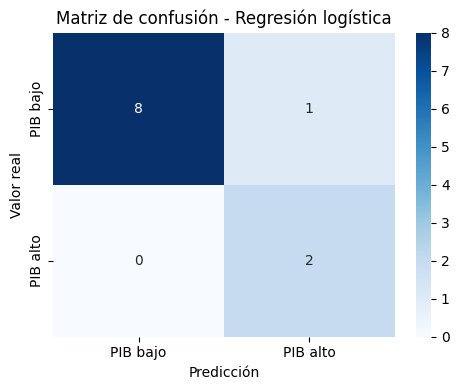

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["PIB bajo", "PIB alto"],
    yticklabels=["PIB bajo", "PIB alto"]
)

plt.title("Matriz de confusión - Regresión logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

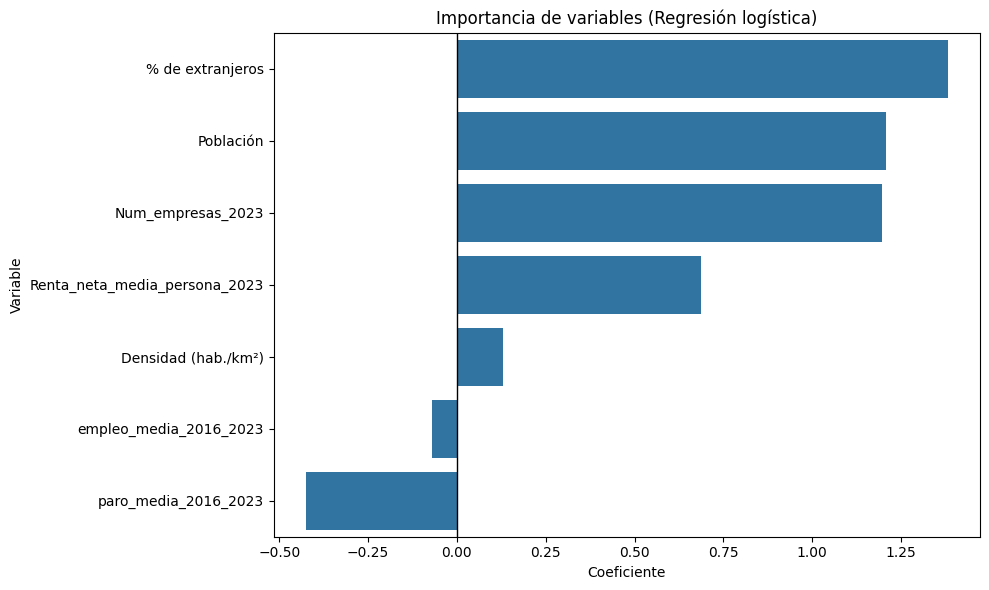

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Dataframe de coeficientes ya calculado
# coef_df = pd.DataFrame({
#     "Variable": features,
#     "Coeficiente": model.coef_[0]
# }).sort_values(by="Coeficiente", ascending=False)

# # Orden descendente por importancia absoluta (más interpretativo)
# coef_df["Abs_Coef"] = coef_df["Coeficiente"].abs()
# coef_df = coef_df.sort_values("Abs_Coef", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df,
    x="Coeficiente",
    y="Variable"
)

plt.title("Importancia de variables (Regresión logística)")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

El modelo de regresión logística obtiene una accuracy de 0.91 en el conjunto de test. La clase mayoritaria, correspondiente a provincias que no pertenecen al grupo de PIB alto, se clasifica con elevada precisión. La clase minoritaria, correspondiente a provincias de PIB alto, presenta un recall de 1.00, aunque estos resultados deben interpretarse con cautela debido al reducido tamaño del dataset y al desbalance entre clases.

La matriz de confusión muestra 8 verdaderos negativos, 2 verdaderos positivos y 1 falso positivo. Esto indica que el modelo identifica correctamente las provincias de alto PIB presentes en el conjunto de test, aunque clasifica una provincia de PIB bajo o medio como si perteneciera al grupo de PIB alto.

Las variables con mayor coeficiente positivo son el porcentaje de población extranjera, la población y el número de empresas. Esto sugiere que las provincias más pobladas, con mayor tejido empresarial y mayor dinamismo demográfico tienen más probabilidad de pertenecer al grupo de PIB alto. La tasa de paro presenta un coeficiente negativo, coherente con la idea de que un mayor desempleo reduce la probabilidad de pertenecer al grupo de mayor PIB.

## 3.2 Modelo No supervisado

In [28]:
# Variables para clustering

features_cluster = [
    "PIB_2023",
    "paro_media_2016_2023",
    "empleo_media_2016_2023",
    "Num_empresas_2023",
    "Población",
    "Densidad (hab./km²)",
    "Renta_neta_media_hogar_2023",
    "Renta_neta_media_persona_2023",
    "Residentes_Extranjero_media_2016_2023",
    "Residentes_España_media_2016_2023"
]

df_cluster = df_model[["Provincia"] + features_cluster].copy()

# Aseguramos que todas las variables del clustering son numéricas
for col in features_cluster:
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors="coerce")
    df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())

# Comprobación
df_cluster[features_cluster].isna().sum()

PIB_2023                                 0
paro_media_2016_2023                     0
empleo_media_2016_2023                   0
Num_empresas_2023                        0
Población                                0
Densidad (hab./km²)                      0
Renta_neta_media_hogar_2023              0
Renta_neta_media_persona_2023            0
Residentes_Extranjero_media_2016_2023    0
Residentes_España_media_2016_2023        0
dtype: int64

K óptimo según método del codo: 5


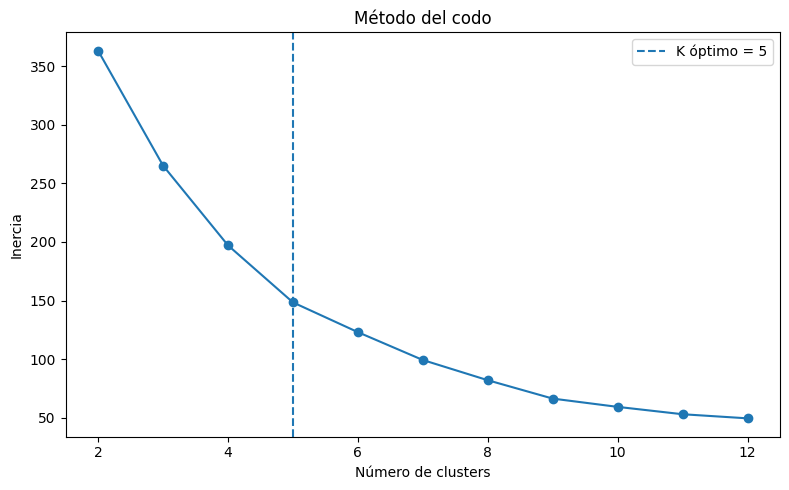

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import matplotlib.pyplot as plt

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df_cluster[features_cluster])

K = range(2, 13)
inertia = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

kneedle = KneeLocator(
    K,
    inertia,
    curve="convex",
    direction="decreasing"
)

k_optimo = kneedle.elbow

print("K óptimo según método del codo:", k_optimo)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
if k_optimo is not None:
    plt.axvline(k_optimo, linestyle="--", label=f"K óptimo = {k_optimo}")
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df_cluster["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

dct_cluster = {}

for cluster in sorted(df_cluster["Cluster"].unique()):
    dct_cluster[int(cluster)] = df_cluster.loc[
        df_cluster["Cluster"] == cluster,
        "Provincia"
    ].tolist()

dct_cluster

{0: ['Albacete',
  'Alicante',
  'Almería',
  'Badajoz',
  'Castellón',
  'Ciudad Real',
  'Cuenca',
  'Cáceres',
  'Cádiz',
  'Córdoba',
  'Granada',
  'Huelva',
  'Jaén',
  'Las Palmas',
  'León',
  'Lugo',
  'Murcia',
  'Málaga',
  'Ourense',
  'Pontevedra',
  'Salamanca',
  'Santa Cruz de Tenerife',
  'Sevilla',
  'Toledo',
  'Zamora',
  'Ávila'],
 1: ['Araba/Álava',
  'Asturias',
  'Bizkaia',
  'Burgos',
  'Cantabria',
  'Gipuzkoa',
  'Girona',
  'Guadalajara',
  'Huesca',
  'La Coruña',
  'La Rioja',
  'Lleida',
  'Navarra',
  'Palencia',
  'Segovia',
  'Soria',
  'Tarragona',
  'Teruel',
  'Valencia',
  'Valladolid',
  'Zaragoza'],
 2: ['Barcelona', 'Madrid'],
 3: ['Ceuta', 'Melilla'],
 4: ['Islas Baleares']}

In [32]:
df_cluster["Cluster"].value_counts().sort_index()

Cluster
0    26
1    21
2     2
3     2
4     1
Name: count, dtype: int64

In [33]:
df_cluster.groupby("Cluster")[features_cluster].mean().round(2)

,PIB_2023,paro_media_2016_2023,empleo_media_2016_2023,Num_empresas_2023,Población,Densidad (hab./km²),Renta_neta_media_hogar_2023,Renta_neta_media_persona_2023,Residentes_Extranjero_media_2016_2023,Residentes_España_media_2016_2023
Cluster,,,,,,,,,,
0,1.931139e+07,17.77,45.74,49112.42,798443.62,100.23,32219.12,13075.73,9297.79,46228.03
1,2.112703e+07,10.70,51.47,41761.76,660688.48,110.03,38002.62,15702.14,10129.11,77235.27
2,2.527514e+08,11.61,55.28,474068.50,6536913.50,828.67,46524.50,17602.00,13930.06,123949.38
3,1.808264e+06,27.04,42.86,3869.50,85317.00,5716.96,45448.00,14310.00,5701.44,47563.81
4,4.150253e+07,12.63,53.98,97784.00,1249844.00,250.37,44812.00,16118.00,239859.25,58792.25


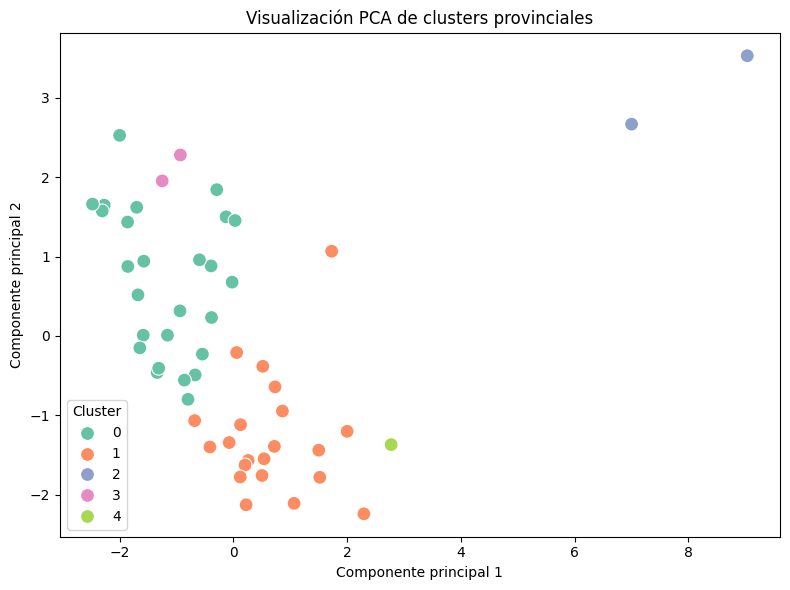

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_cluster_scaled)

df_plot = pd.DataFrame(components, columns=["PC1", "PC2"])
df_plot["Cluster"] = df_cluster["Cluster"].values
df_plot["Provincia"] = df_cluster["Provincia"].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=100
)

plt.title("Visualización PCA de clusters provinciales")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.tight_layout()
plt.show()

El modelo K-means agrupa las provincias en cinco clusters. La elección de K = 5 se basa en el método del codo, que identifica este valor como una solución adecuada para separar perfiles provinciales sin generar demasiados grupos pequeños.

**Cluster 0:**  
(Albacete, Alicante, Almería, Badajoz, Castellón, Ciudad Real, Cuenca, Cáceres, Cádiz, Córdoba, Granada, Huelva, Jaén, Las Palmas, León, Lugo, Murcia, Málaga, Ourense, Pontevedra, Salamanca, Santa Cruz de Tenerife, Sevilla, Toledo, Zamora y Ávila)

Este grupo reúne principalmente provincias con un perfil económico intermedio o más moderado. En comparación con el cluster 1, presenta menor renta media, menor tasa de empleo y una tasa de paro más alta. Incluye muchas provincias del sur, del interior y algunos territorios con peso turístico o poblacional.

**Cluster 1:**  
(Araba/Álava, Asturias, Bizkaia, Burgos, Cantabria, Gipuzkoa, Girona, Guadalajara, Huesca, La Coruña, La Rioja, Lleida, Navarra, Palencia, Segovia, Soria, Tarragona, Teruel, Valencia, Valladolid y Zaragoza)

Este cluster agrupa provincias con un perfil económico más consolidado. Presenta mayor renta media, mayor tasa de empleo y menor tasa de paro que el cluster 0. Incluye varias provincias del norte, territorios industriales y algunos polos regionales como Valencia, Valladolid o Zaragoza.

**Cluster 2:**  
(Barcelona y Madrid)

Este cluster recoge las dos principales áreas económicas del país. Se separan claramente del resto por su mayor PIB, población, número de empresas y densidad de actividad económica.

**Cluster 3:**  
(Ceuta y Melilla)

Ceuta y Melilla forman un grupo diferenciado por sus características territoriales específicas. Presentan menor PIB y menor número de empresas, pero una densidad de población muy elevada y una tasa de paro media superior al resto de clusters. Además, en las variables turísticas no aparecían en la fuente utilizada, por lo que sus valores fueron imputados en el dataset de modelado.

**Cluster 4:**  
(Islas Baleares)

Islas Baleares queda como un cluster individual. Esto se explica principalmente por su perfil turístico, especialmente por el valor muy alto de residentes extranjeros respecto al resto de grupos, además de una renta y actividad económica relativamente elevadas.

En conjunto, el clustering muestra que las provincias españolas no forman un bloque homogéneo, sino que se agrupan en perfiles territoriales diferenciados: grandes polos económicos, provincias de desarrollo medio-alto, provincias de perfil más moderado y casos singulares como Baleares, Ceuta y Melilla.

## 3.3 contraste de hipótesis

Comparar si las provincias "Ricas" tienen más empresas que las no ricas

H0: No hay relación entre PIB y número de empresas
H1: Sí hay relación

In [35]:
from scipy import stats

# Separar grupos
group_high = df_model[df_model["PIB_alto"] == 1]["Num_empresas_2023"].dropna()
group_low = df_model[df_model["PIB_alto"] == 0]["Num_empresas_2023"].dropna()

# Test de normalidad (Shapiro)
shapiro_high = stats.shapiro(group_high)
shapiro_low = stats.shapiro(group_low)

print("Shapiro high:", shapiro_high)
print("Shapiro low:", shapiro_low)

# Si no son normales → Mann-Whitney (recomendado)
stat, p_value = stats.mannwhitneyu(group_high, group_low, alternative="two-sided")

print("\nMann-Whitney U test")
print("stat:", stat)
print("p-value:", p_value)

Shapiro high: ShapiroResult(statistic=np.float64(0.6980684641488455), pvalue=np.float64(0.0004417674793834739))
Shapiro low: ShapiroResult(statistic=np.float64(0.9373386299304021), pvalue=np.float64(0.025488959214092912))

Mann-Whitney U test
stat: 444.0
p-value: 1.0368692619364275e-06


Para complementar el p-value calculamos el tamaño del efecto mediante la d de Cohen. Este estadístico permite valorar la magnitud práctica de la diferencia entre ambos grupos, más allá de su significación estadística.

In [36]:
import numpy as np

group_high = df_model[df_model["PIB_alto"] == 1]["Num_empresas_2023"].dropna()
group_low = df_model[df_model["PIB_alto"] == 0]["Num_empresas_2023"].dropna()

mean_high = group_high.mean()
mean_low = group_low.mean()

std_high = group_high.std()
std_low = group_low.std()

n1 = len(group_high)
n2 = len(group_low)

# pooled std
pooled_std = np.sqrt(
    ((n1 - 1)*std_high**2 + (n2 - 1)*std_low**2) / (n1 + n2 - 2)
)

cohen_d = (mean_high - mean_low) / pooled_std

print("Cohen's d:", cohen_d)

Cohen's d: 2.008339268472596


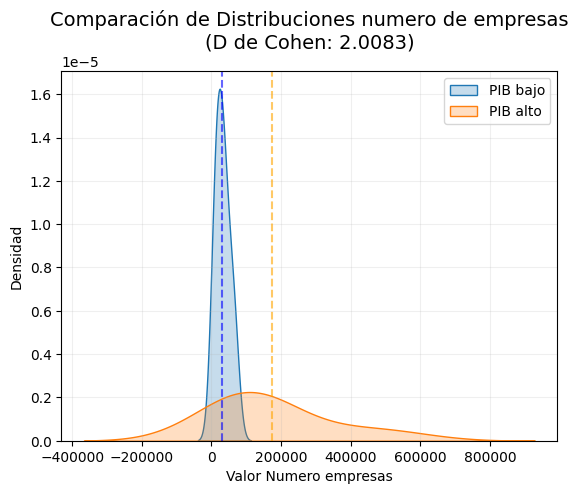

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtramos los datos
data_low_pib = df_model.loc[df_model["PIB_alto"] == 0, 'Num_empresas_2023']
data_high_pib = df_model.loc[df_model["PIB_alto"] == 1, 'Num_empresas_2023']

# Creamos el gráfico de densidad
sns.kdeplot(data_low_pib, label='PIB bajo', fill=True, bw_adjust=1.5)
sns.kdeplot(data_high_pib, label='PIB alto', fill=True, bw_adjust=1.5)

# Añadimos las líneas de las medias para marcar la "distancia"
plt.axvline(data_low_pib.mean(), color='blue', linestyle='--', alpha=0.6)
plt.axvline(data_high_pib.mean(), color='orange', linestyle='--', alpha=0.6)

plt.title(f"Comparación de Distribuciones numero de empresas\n(D de Cohen: {cohen_d:.4f})", fontsize=14)
plt.xlabel("Valor Numero empresas")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, alpha=0.2)

El análisis de contraste de hipótesis entre provincias con PIB alto y PIB bajo (definido como el 20% superior del PIB en 2023) muestra diferencias estadísticamente significativas en el número de empresas.

El test no paramétrico de Mann-Whitney U indica un p-value muy inferior a 0.05, por lo que se rechaza la hipótesis nula de igualdad de distribuciones. Esto sugiere que el tejido empresarial difiere de forma significativa entre ambos grupos de provincias.

El análisis de tamaño del efecto mediante el estadístico d de Cohen permite evaluar la magnitud de esta diferencia, observándose un efecto relevante entre ambos grupos. Esto indica que no solo existen diferencias estadísticamente significativas, sino también diferencias con importancia práctica. Un valor de d = 2.01 se sitúa muy por encima del umbral considerado como efecto grande (0.8), lo que indica una separación muy marcada entre ambos grupos. En términos prácticos, esto significa que las provincias con PIB alto tienen un tejido empresarial sustancialmente mayor que las provincias con PIB bajo, con muy poco solapamiento entre distribuciones.

La visualización mediante KDE plot muestra que las provincias con PIB bajo concentran la mayor parte de su distribución en valores reducidos de número de empresas, mientras que las provincias con PIB alto presentan una distribución desplazada hacia valores superiores y con mayor dispersión. En términos generales, el grupo de alto PIB presenta una media significativamente mayor de empresas, lo que refuerza la relación positiva entre actividad empresarial y nivel de riqueza provincial.

En conjunto, los resultados apoyan la existencia de una relación estructural entre el desarrollo económico provincial y el tamaño del tejido empresarial, evidenciando que las provincias económicamente más fuertes tienden a concentrar un mayor número de empresas y mayor heterogeneidad en su estructura productiva.

## 3.4 Analisis del resto del Dataset

## 3.4 Análisis descriptivo del resto del dataset

En este apartado se realiza un análisis descriptivo adicional del dataset limpio para complementar los modelos supervisado y no supervisado. El objetivo es responder a las preguntas planteadas inicialmente mediante tablas y visualizaciones, analizando el PIB, la población, el tejido empresarial, la renta, el presupuesto provincial y la evolución temporal del PIB.

### 3.4.1 Provincias con mayor PIB en 2023

En primer lugar, se analiza qué provincias presentan un mayor nivel de PIB en 2023. Esta variable se utiliza como indicador principal del peso económico provincial.

In [38]:
# Ranking de provincias por PIB en 2023
top_pib_2023 = (
    df_model[["Provincia", "PIB_2023", "PIB_alto"]]
    .sort_values("PIB_2023", ascending=False)
    .head(15)
)

top_pib_2023

,Provincia,PIB_2023,PIB_alto
31,Madrid,295939562,1
6,Barcelona,209563285,1
47,Valencia,75521155,1
42,Sevilla,48846749,1
1,Alicante,46472807,1
7,Bizkaia,44229902,1
23,Islas Baleares,41502526,1
34,Málaga,41235144,1
33,Murcia,39838741,1
50,Zaragoza,34285966,1


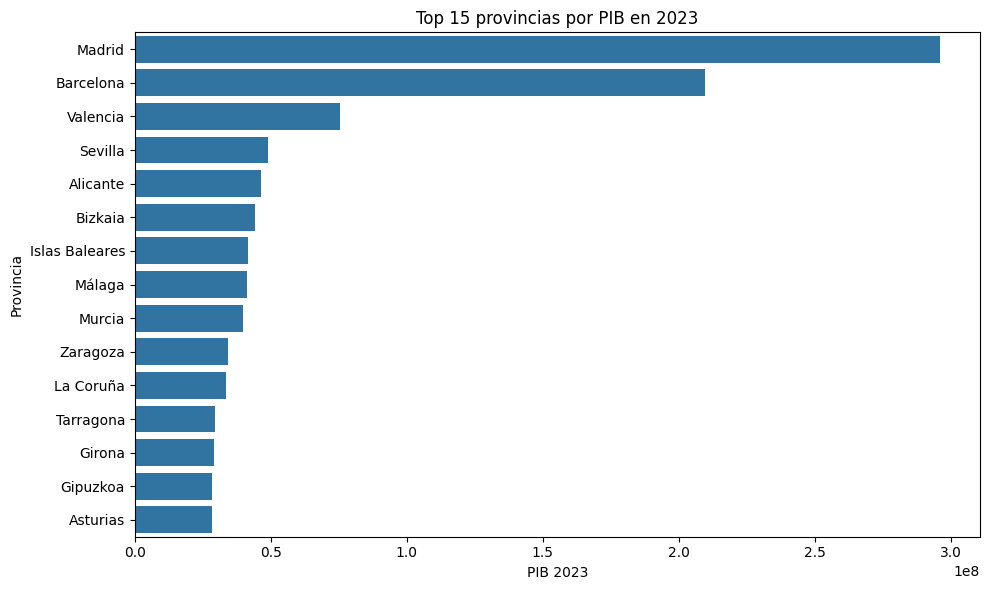

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_pib_2023,
    x="PIB_2023",
    y="Provincia"
)

plt.title("Top 15 provincias por PIB en 2023")
plt.xlabel("PIB 2023")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

In [40]:
# Peso relativo del PIB provincial sobre el total del dataset
df_pib_peso = df_model[["Provincia", "PIB_2023"]].copy()
df_pib_peso["Peso_PIB_2023_%"] = (
    df_pib_peso["PIB_2023"] / df_pib_peso["PIB_2023"].sum() * 100
)

df_pib_peso_top = (
    df_pib_peso
    .sort_values("Peso_PIB_2023_%", ascending=False)
    .head(15)
)

df_pib_peso_top

,Provincia,PIB_2023,Peso_PIB_2023_%
31,Madrid,295939562,19.776958
6,Barcelona,209563285,14.004631
47,Valencia,75521155,5.046905
42,Sevilla,48846749,3.264316
1,Alicante,46472807,3.105671
7,Bizkaia,44229902,2.955782
23,Islas Baleares,41502526,2.773518
34,Málaga,41235144,2.755650
33,Murcia,39838741,2.662331
50,Zaragoza,34285966,2.291252


In [41]:
peso_top5 = df_pib_peso_top.head(5)["Peso_PIB_2023_%"].sum()
peso_top10 = df_pib_peso_top.head(10)["Peso_PIB_2023_%"].sum()

print(f"Peso acumulado del top 5: {peso_top5:.2f}%")
print(f"Peso acumulado del top 10: {peso_top10:.2f}%")

Peso acumulado del top 5: 45.20%
Peso acumulado del top 10: 58.64%


El ranking de PIB provincial en 2023 muestra una fuerte concentración territorial de la actividad económica. Madrid y Barcelona ocupan claramente las dos primeras posiciones, con un peso conjunto aproximado del 33,8% del PIB total del dataset. Esta diferencia también se observa visualmente en el gráfico, donde ambas provincias destacan de forma clara respecto al resto.

A partir de la tercera posición aparecen provincias con gran peso demográfico, empresarial, industrial o turístico, como Valencia, Sevilla, Alicante, Bizkaia, Islas Baleares, Málaga, Zaragoza o La Coruña. En conjunto, las cinco primeras provincias concentran el 45,2% del PIB total, mientras que las diez primeras alcanzan el 58,6%.

Estos resultados indican que el desarrollo económico, medido en términos de PIB total, no se distribuye de forma homogénea entre las provincias, sino que se concentra en un número reducido de territorios.

### 3.4.2 Relación entre PIB, población, densidad y tejido empresarial

A continuación analizamos si el PIB provincial en 2023 está relacionado con variables estructurales como la población, la densidad de población y el número de empresas. Para ello utilizamos gráficos de dispersión y una matriz de correlaciones entre las principales variables económicas y demográficas.

In [42]:
variables_relacion_pib = [
    "PIB_2023",
    "Población",
    "Densidad (hab./km²)",
    "Num_empresas_2023",
    "Renta_neta_media_persona_2023",
    "Renta_neta_media_hogar_2023",
    "paro_media_2016_2023",
    "empleo_media_2016_2023",
    "actividad_media_2016_2023"
]

corr_pib = (
    df_model[variables_relacion_pib]
    .corr(numeric_only=True)["PIB_2023"]
    .sort_values(ascending=False)
)

corr_pib

PIB_2023                         1.000000
Num_empresas_2023                0.983847
Población                        0.981227
Renta_neta_media_hogar_2023      0.474891
actividad_media_2016_2023        0.382460
Renta_neta_media_persona_2023    0.367404
empleo_media_2016_2023           0.348543
Densidad (hab./km²)              0.030000
paro_media_2016_2023            -0.108218
Name: PIB_2023, dtype: float64

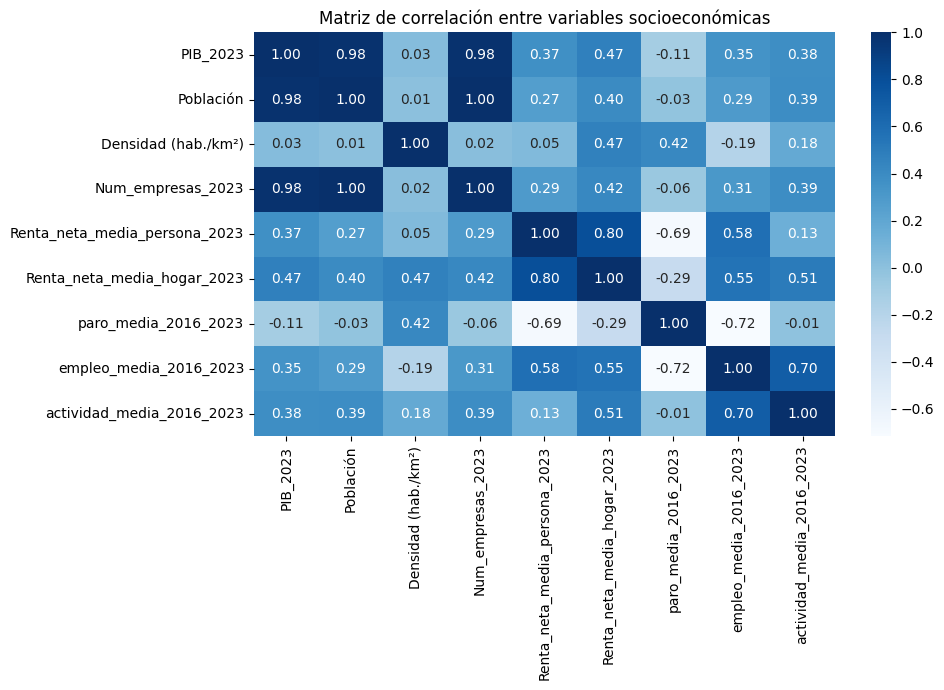

In [43]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df_model[variables_relacion_pib].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Matriz de correlación entre variables socioeconómicas")
plt.tight_layout()
plt.show()

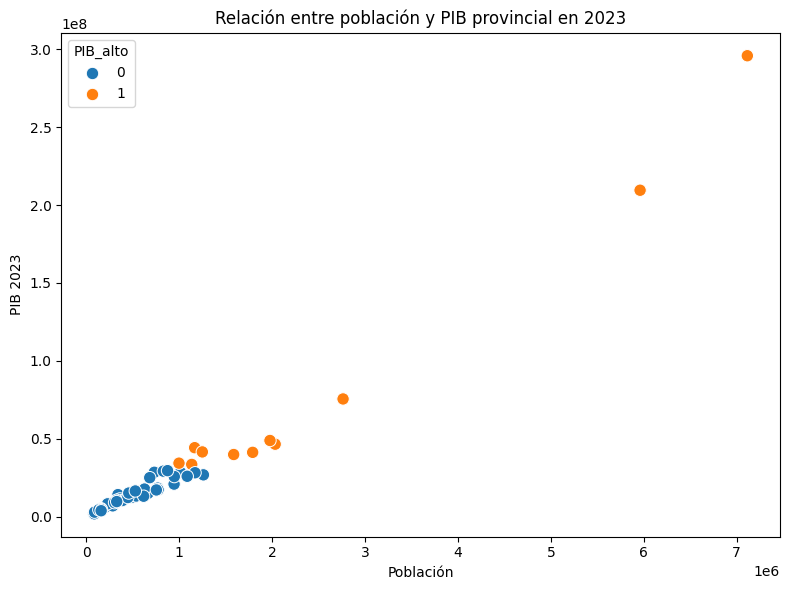

In [44]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_model,
    x="Población",
    y="PIB_2023",
    hue="PIB_alto",
    s=80
)

plt.title("Relación entre población y PIB provincial en 2023")
plt.xlabel("Población")
plt.ylabel("PIB 2023")
plt.tight_layout()
plt.show()

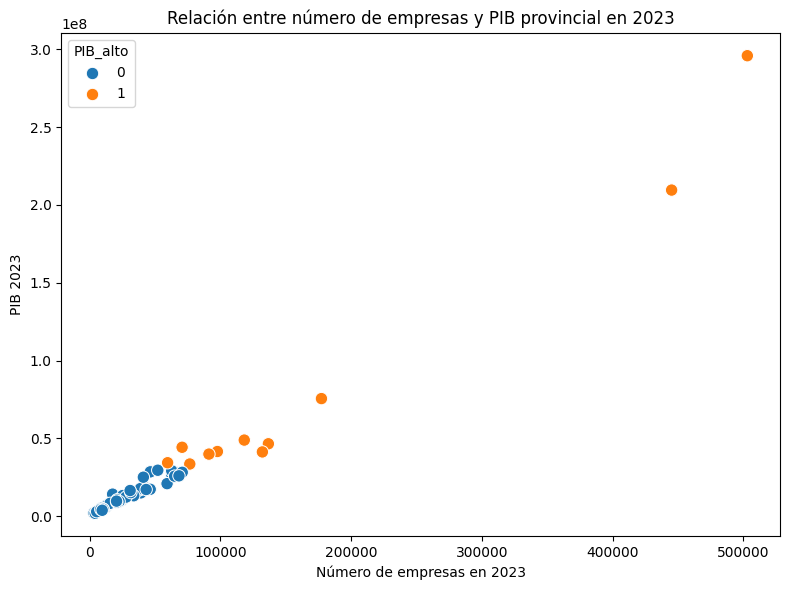

In [45]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_model,
    x="Num_empresas_2023",
    y="PIB_2023",
    hue="PIB_alto",
    s=80
)

plt.title("Relación entre número de empresas y PIB provincial en 2023")
plt.xlabel("Número de empresas en 2023")
plt.ylabel("PIB 2023")
plt.tight_layout()
plt.show()

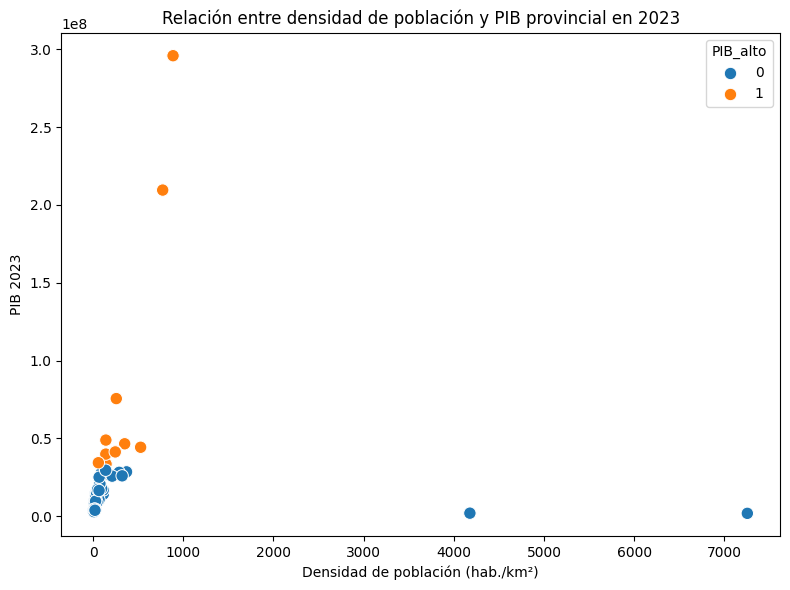

In [46]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_model,
    x="Densidad (hab./km²)",
    y="PIB_2023",
    hue="PIB_alto",
    s=80
)

plt.title("Relación entre densidad de población y PIB provincial en 2023")
plt.xlabel("Densidad de población (hab./km²)")
plt.ylabel("PIB 2023")
plt.tight_layout()
plt.show()

La matriz de correlaciones muestra que el PIB provincial en 2023 está fuertemente relacionado con la población y con el número de empresas, ambas con correlaciones próximas a 0.98. Esto indica que el PIB total depende en gran medida del tamaño demográfico y del volumen de actividad empresarial de cada provincia.

Los gráficos de dispersión confirman esta relación: las provincias con mayor población y mayor número de empresas tienden a situarse también en los valores más altos de PIB. Madrid y Barcelona aparecen claramente separadas del resto, lo que refuerza la idea de una fuerte concentración económica en los principales polos urbanos y empresariales.

En cambio, la densidad de población no presenta una relación clara con el PIB provincial, con una correlación cercana a cero. Esto sugiere que una mayor concentración de habitantes por km² no implica necesariamente un mayor PIB total. En este caso, el tamaño poblacional y el tejido empresarial parecen ser factores más relevantes que la densidad.

Por último, las variables de renta presentan una relación positiva pero más moderada con el PIB. Esto indica que el PIB total y la renta media no miden exactamente lo mismo: el primero refleja el tamaño económico agregado de la provincia, mientras que la renta media aproxima mejor el nivel económico individual o familiar.

### 3.4.3 Evolución del PIB provincial entre 2016 y 2023

A continuación se analiza la evolución del PIB provincial durante el periodo 2016-2023. Para ello se calcula tanto el crecimiento absoluto como el crecimiento porcentual entre ambos años, lo que permite identificar qué provincias han aumentado más su PIB en términos totales y relativos.

In [48]:
# Evolución del PIB entre 2016 y 2023 usando el dataset integrado completo
df_pib_evol = df[["Provincia", "PIB_2016", "PIB_2023"]].copy()

df_pib_evol["Crecimiento_abs_2016_2023"] = (
    df_pib_evol["PIB_2023"] - df_pib_evol["PIB_2016"]
)

df_pib_evol["Crecimiento_pct_2016_2023"] = (
    df_pib_evol["Crecimiento_abs_2016_2023"] / df_pib_evol["PIB_2016"] * 100
)

df_pib_evol.sort_values("Crecimiento_pct_2016_2023", ascending=False).head(15)

,Provincia,PIB_2016,PIB_2023,Crecimiento_abs_2016_2023,Crecimiento_pct_2016_2023
39,Salamanca,6511439,9604292,3092853,47.498763
20,Guadalajara,4750576,6878584,2128008,44.794736
34,Málaga,28513572,41235144,12721572,44.615848
21,Huelva,9288980,13183665,3894685,41.928016
36,Ourense,6317422,8914517,2597095,41.110045
14,Cáceres,7292966,10265612,2972646,40.760453
18,Girona,20769493,29157484,8387991,40.386113
46,Toledo,12179643,17074065,4894422,40.185267
31,Madrid,214469101,295939562,81470461,37.987039
23,Islas Baleares,30223284,41502526,11279242,37.319710


In [49]:
# Provincias con mayor crecimiento porcentual

top_crecimiento_pct = (
    df_pib_evol
    .sort_values("Crecimiento_pct_2016_2023", ascending=False)
    .head(15)
)

top_crecimiento_pct

,Provincia,PIB_2016,PIB_2023,Crecimiento_abs_2016_2023,Crecimiento_pct_2016_2023
39,Salamanca,6511439,9604292,3092853,47.498763
20,Guadalajara,4750576,6878584,2128008,44.794736
34,Málaga,28513572,41235144,12721572,44.615848
21,Huelva,9288980,13183665,3894685,41.928016
36,Ourense,6317422,8914517,2597095,41.110045
14,Cáceres,7292966,10265612,2972646,40.760453
18,Girona,20769493,29157484,8387991,40.386113
46,Toledo,12179643,17074065,4894422,40.185267
31,Madrid,214469101,295939562,81470461,37.987039
23,Islas Baleares,30223284,41502526,11279242,37.319710


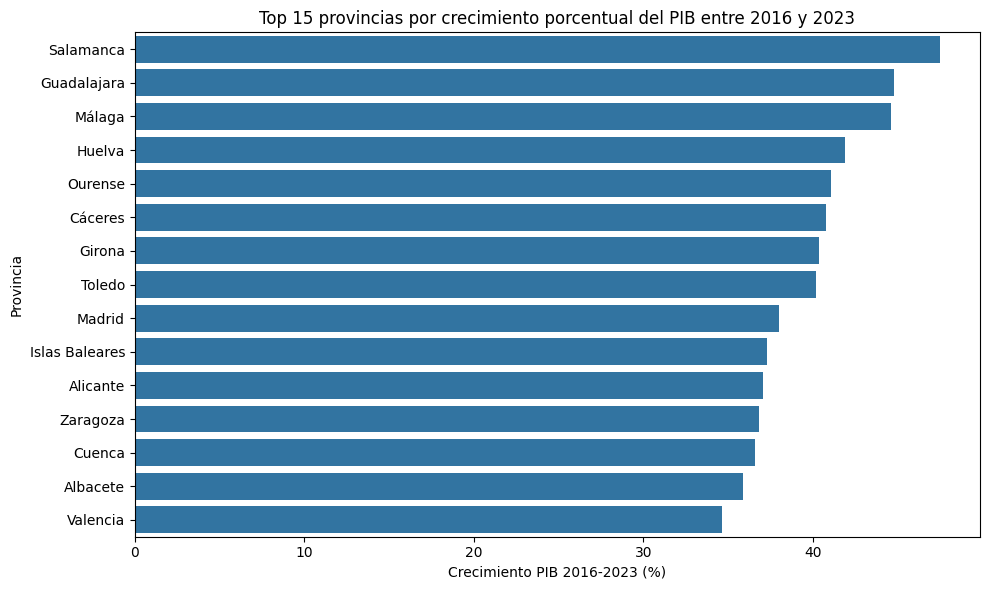

In [50]:
# Gráfico crecimiento porcentual
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_crecimiento_pct,
    x="Crecimiento_pct_2016_2023",
    y="Provincia"
)

plt.title("Top 15 provincias por crecimiento porcentual del PIB entre 2016 y 2023")
plt.xlabel("Crecimiento PIB 2016-2023 (%)")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

In [51]:
# Provincias con mayor crecimiento absoluto
top_crecimiento_abs = (
    df_pib_evol
    .sort_values("Crecimiento_abs_2016_2023", ascending=False)
    .head(15)
)

top_crecimiento_abs

,Provincia,PIB_2016,PIB_2023,Crecimiento_abs_2016_2023,Crecimiento_pct_2016_2023
31,Madrid,214469101,295939562,81470461,37.987039
6,Barcelona,158516150,209563285,51047135,32.203113
47,Valencia,56083303,75521155,19437852,34.658893
34,Málaga,28513572,41235144,12721572,44.615848
1,Alicante,33899084,46472807,12573723,37.091631
42,Sevilla,36674889,48846749,12171860,33.188539
23,Islas Baleares,30223284,41502526,11279242,37.319710
7,Bizkaia,33686330,44229902,10543572,31.299260
33,Murcia,30009138,39838741,9829603,32.755366
50,Zaragoza,25061759,34285966,9224207,36.805904


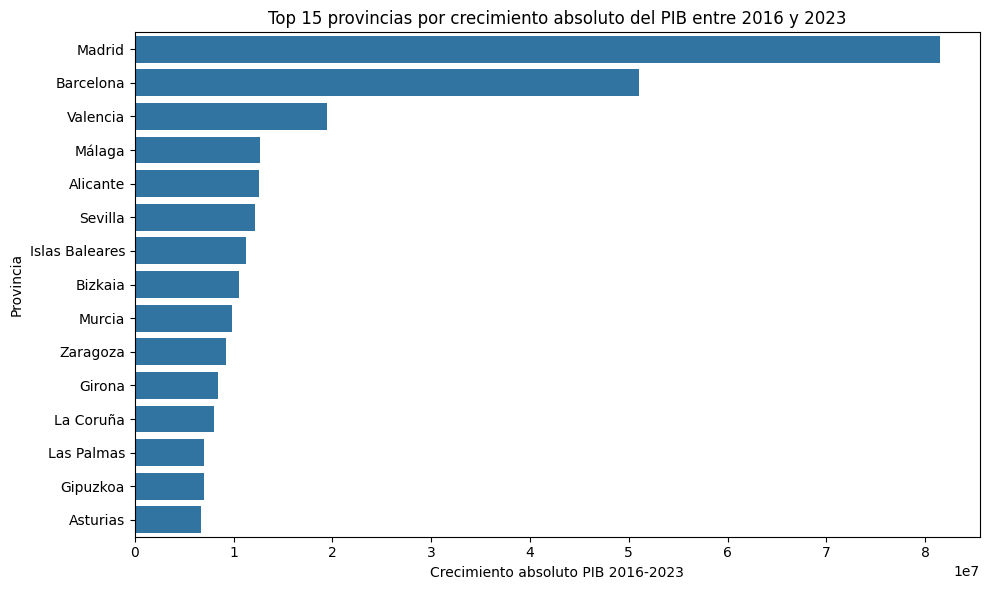

In [52]:
# Gráfico crecimiento absoluto
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_crecimiento_abs,
    x="Crecimiento_abs_2016_2023",
    y="Provincia"
)

plt.title("Top 15 provincias por crecimiento absoluto del PIB entre 2016 y 2023")
plt.xlabel("Crecimiento absoluto PIB 2016-2023")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

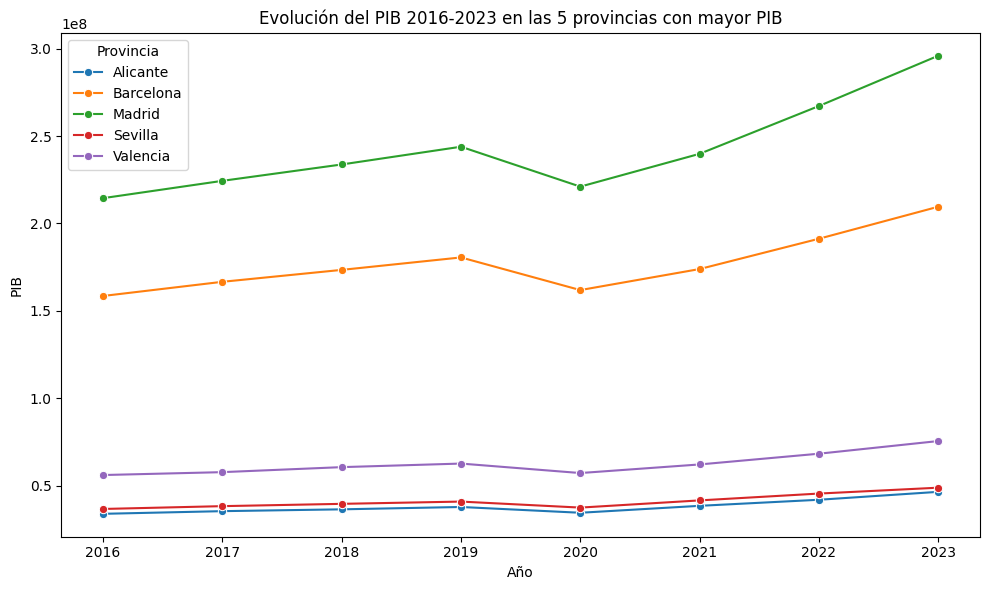

In [53]:
# Evolución anual de las 5 provincias con mayor PIB
pib_cols = [f"PIB_{year}" for year in range(2016, 2024)]

top_5_provincias = (
    df
    .sort_values("PIB_2023", ascending=False)
    .head(5)["Provincia"]
    .tolist()
)

df_pib_long = df[df["Provincia"].isin(top_5_provincias)][
    ["Provincia"] + pib_cols
].melt(
    id_vars="Provincia",
    value_vars=pib_cols,
    var_name="Año",
    value_name="PIB"
)

df_pib_long["Año"] = df_pib_long["Año"].str.replace("PIB_", "").astype(int)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_pib_long,
    x="Año",
    y="PIB",
    hue="Provincia",
    marker="o"
)

plt.title("Evolución del PIB 2016-2023 en las 5 provincias con mayor PIB")
plt.xlabel("Año")
plt.ylabel("PIB")
plt.tight_layout()
plt.show()

La evolución del PIB entre 2016 y 2023 muestra un crecimiento generalizado en las provincias analizadas según los valores registrados en el dataset. El crecimiento porcentual medio se sitúa en torno al 31,2%, con una mediana muy similar, lo que indica que la mayoría de provincias se concentran alrededor de ese nivel de crecimiento relativo. El crecimiento mínimo es del 17,8% y el máximo alcanza el 47,5%.

Los resultados cambian según se observe el crecimiento porcentual o el crecimiento absoluto. En términos porcentuales, destacan provincias como Salamanca, Guadalajara, Málaga, Huelva, Ourense o Cáceres. Este ranking refleja qué territorios han aumentado más su PIB respecto a su nivel inicial en 2016, por lo que algunas provincias con menor PIB absoluto pueden aparecer en posiciones altas.

En cambio, el crecimiento absoluto está liderado por las provincias con mayor tamaño económico, especialmente Madrid y Barcelona, seguidas de Valencia, Málaga, Alicante, Sevilla e Islas Baleares. Esto indica que los grandes polos económicos no solo tienen mayor PIB en 2023, sino que también concentran gran parte del aumento total del PIB durante el periodo.

La evolución anual de las cinco provincias con mayor PIB muestra una tendencia creciente entre 2016 y 2023, con una caída visible en 2020 y una recuperación posterior. Madrid y Barcelona mantienen durante todo el periodo una distancia clara respecto al resto, reforzando la idea de concentración económica territorial.

In [54]:
df_pib_evol[
    ["Crecimiento_abs_2016_2023", "Crecimiento_pct_2016_2023"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Crecimiento_abs_2016_2023,52.0,7.202928e+06,1.291771e+07,300914.000000,2.121473e+06,3.544432e+06,6.967550e+06,8.147046e+07
Crecimiento_pct_2016_2023,52.0,3.124081e+01,7.095408e+00,17.807155,2.653324e+01,3.126467e+01,3.604202e+01,4.749876e+01


### 3.4.4 Peso presupuestario provincial

A continuación se analiza el presupuesto provincial como aproximación al peso administrativo o presupuestario de cada territorio. Esta variable permite identificar qué provincias cuentan con mayor volumen presupuestario y comprobar si existe relación con el PIB y la población.

In [55]:
# Ranking de provincias por presupuesto
top_presupuesto = (
    df_model[["Provincia", "Presupuesto (€)", "PIB_2023", "Población"]]
    .sort_values("Presupuesto (€)", ascending=False)
    .head(15)
)

top_presupuesto

,Provincia,Presupuesto (€),PIB_2023,Población
31,Madrid,5.703000e+09,295939562,7113886
6,Barcelona,3.595900e+09,209563285,5959941
42,Sevilla,1.158000e+09,48846749,1977664
47,Valencia,1.042800e+09,75521155,2763996
34,Málaga,9.766000e+08,41235144,1791183
50,Zaragoza,8.952912e+08,34285966,998443
7,Bizkaia,6.635000e+08,44229902,1167233
16,Córdoba,5.520000e+08,17217243,773163
23,Islas Baleares,4.870000e+08,41502526,1249844
27,Las Palmas,4.850000e+08,28124631,1171547


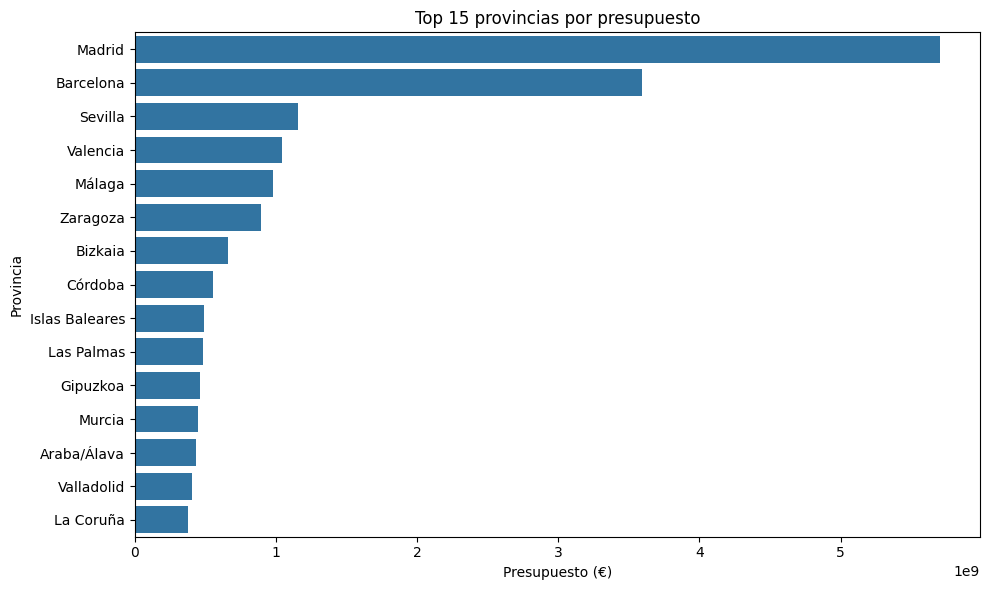

In [56]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_presupuesto,
    x="Presupuesto (€)",
    y="Provincia"
)

plt.title("Top 15 provincias por presupuesto")
plt.xlabel("Presupuesto (€)")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

In [57]:
# Correlación presupuesto, PIB y población
variables_presupuesto = [
    "Presupuesto (€)",
    "PIB_2023",
    "Población",
    "Num_empresas_2023",
    "Renta_neta_media_hogar_2023",
    "Renta_neta_media_persona_2023"
]

corr_presupuesto = (
    df_model[variables_presupuesto]
    .corr(numeric_only=True)["Presupuesto (€)"]
    .sort_values(ascending=False)
)

corr_presupuesto

Presupuesto (€)                  1.000000
PIB_2023                         0.979346
Num_empresas_2023                0.949944
Población                        0.946163
Renta_neta_media_hogar_2023      0.482507
Renta_neta_media_persona_2023    0.378498
Name: Presupuesto (€), dtype: float64

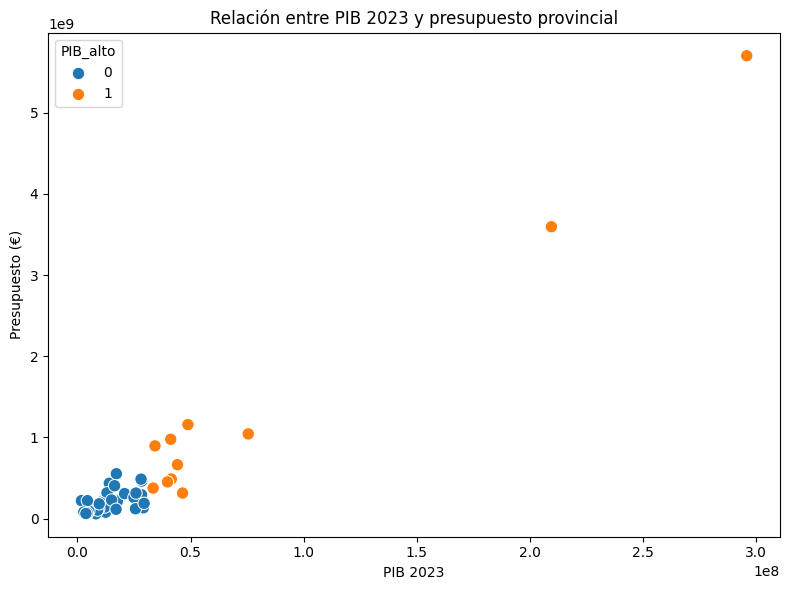

In [58]:
# Relación presupuesto vs PIB
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_model,
    x="PIB_2023",
    y="Presupuesto (€)",
    hue="PIB_alto",
    s=80
)

plt.title("Relación entre PIB 2023 y presupuesto provincial")
plt.xlabel("PIB 2023")
plt.ylabel("Presupuesto (€)")
plt.tight_layout()
plt.show()

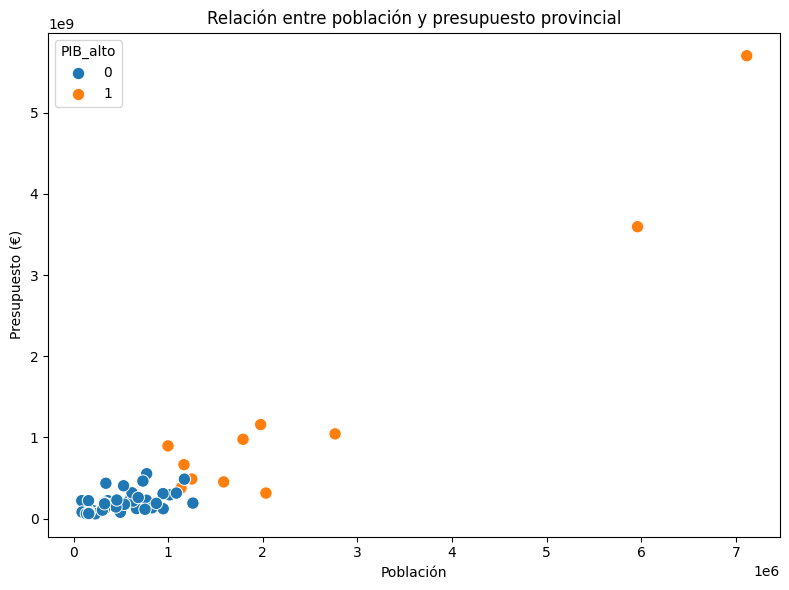

In [59]:
# Relación presupuesto vs población
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_model,
    x="Población",
    y="Presupuesto (€)",
    hue="PIB_alto",
    s=80
)

plt.title("Relación entre población y presupuesto provincial")
plt.xlabel("Población")
plt.ylabel("Presupuesto (€)")
plt.tight_layout()
plt.show()

El análisis del presupuesto provincial muestra una concentración similar a la observada en el PIB. Madrid y Barcelona presentan los mayores presupuestos, claramente por encima del resto de provincias. A continuación aparecen territorios con gran peso poblacional, económico o administrativo, como Sevilla, Valencia, Málaga, Zaragoza, Bizkaia o Córdoba.

La matriz de correlaciones muestra una relación muy fuerte entre presupuesto y PIB provincial, con una correlación cercana a 0.98. También se observa una asociación elevada con la población y el número de empresas. Esto indica que el presupuesto provincial está muy relacionado con el tamaño económico y demográfico de cada territorio.

En cambio, la relación con la renta media por persona y por hogar es positiva pero más moderada. Esto sugiere que el presupuesto no depende tanto del nivel medio de renta de los habitantes, sino del volumen global de población, actividad económica y estructura administrativa de cada provincia.

En conjunto, los resultados muestran que las provincias con mayor peso presupuestario coinciden en gran medida con las provincias de mayor PIB y población. Por tanto, el presupuesto refuerza la idea de concentración territorial del peso económico y administrativo.

### 3.4.5 Renta y mercado laboral

A continuación se analizan las variables de renta y mercado laboral para comprobar si las provincias con mayor PIB total también presentan mejores indicadores medios de bienestar económico y empleo. Para ello se comparan la renta media por persona, la renta media por hogar, la tasa media de paro y la tasa media de empleo entre provincias con PIB alto y el resto.

In [60]:
# Comparación de indicadores medios entre provincias con PIB alto y el resto
variables_renta_laboral = [
    "Renta_neta_media_persona_2023",
    "Renta_neta_media_hogar_2023",
    "paro_media_2016_2023",
    "empleo_media_2016_2023",
    "actividad_media_2016_2023"
]

resumen_renta_laboral = (
    df_model
    .groupby("PIB_alto")[variables_renta_laboral]
    .mean()
    .round(2)
)

resumen_renta_laboral

,Renta_neta_media_persona_2023,Renta_neta_media_hogar_2023,paro_media_2016_2023,empleo_media_2016_2023,actividad_media_2016_2023
PIB_alto,,,,,
0,14232.17,35021.66,15.17,47.87,56.44
1,15103.36,38965.55,14.08,50.72,59.02


In [61]:
# Ranking de renta media por persona
top_renta_persona = (
    df_model[
        [
            "Provincia",
            "Renta_neta_media_persona_2023",
            "Renta_neta_media_hogar_2023",
            "PIB_2023",
            "PIB_alto"
        ]
    ]
    .sort_values("Renta_neta_media_persona_2023", ascending=False)
    .head(15)
)

top_renta_persona

,Provincia,Renta_neta_media_persona_2023,Renta_neta_media_hogar_2023,PIB_2023,PIB_alto
17,Gipuzkoa,19616,46514,28427601,0
7,Bizkaia,18738,44425,44229902,1
31,Madrid,18142,48806,295939562,1
3,Araba/Álava,17806,41914,14090604,0
6,Barcelona,17062,44243,209563285,1
35,Navarra,16423,42714,24975376,0
23,Islas Baleares,16118,44812,41502526,1
8,Burgos,15988,36605,11303996,0
4,Asturias,15784,35265,28350371,0
50,Zaragoza,15650,38230,34285966,1


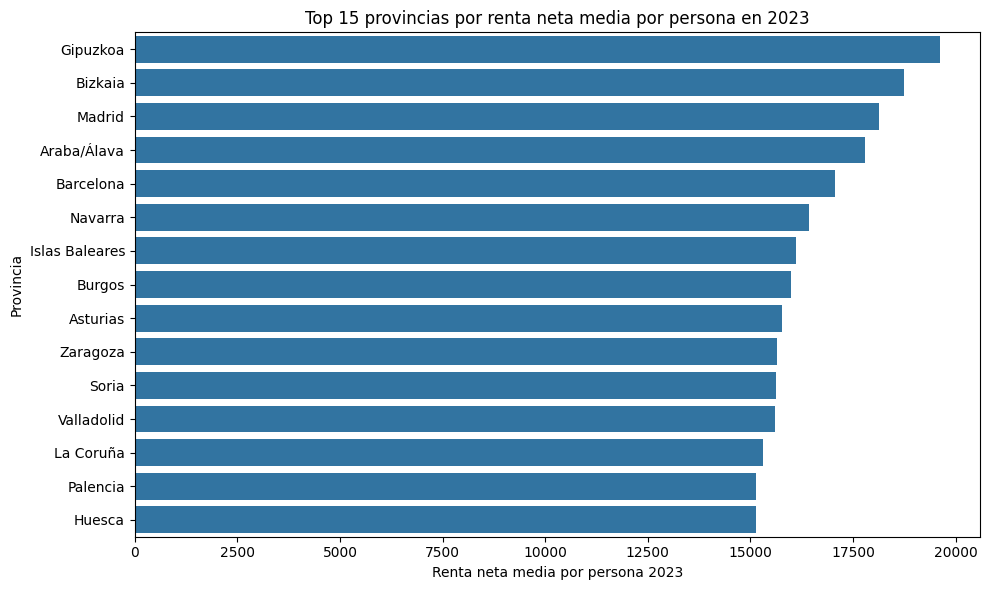

In [62]:
# Gráfico renta media por persona
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_renta_persona,
    x="Renta_neta_media_persona_2023",
    y="Provincia"
)

plt.title("Top 15 provincias por renta neta media por persona en 2023")
plt.xlabel("Renta neta media por persona 2023")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

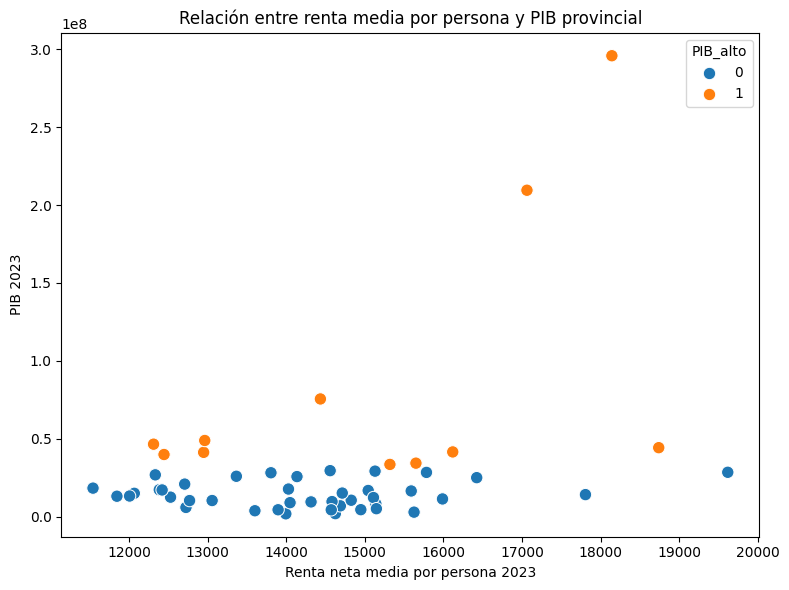

In [63]:
# PIB vs renta por persona
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_model,
    x="Renta_neta_media_persona_2023",
    y="PIB_2023",
    hue="PIB_alto",
    s=80
)

plt.title("Relación entre renta media por persona y PIB provincial")
plt.xlabel("Renta neta media por persona 2023")
plt.ylabel("PIB 2023")
plt.tight_layout()
plt.show()

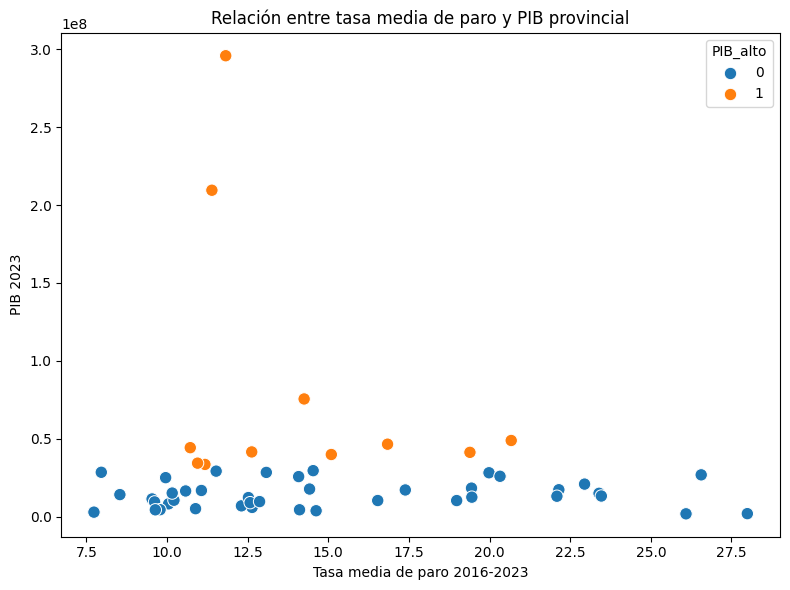

In [64]:
# PIB vs paro medio
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_model,
    x="paro_media_2016_2023",
    y="PIB_2023",
    hue="PIB_alto",
    s=80
)

plt.title("Relación entre tasa media de paro y PIB provincial")
plt.xlabel("Tasa media de paro 2016-2023")
plt.ylabel("PIB 2023")
plt.tight_layout()
plt.show()

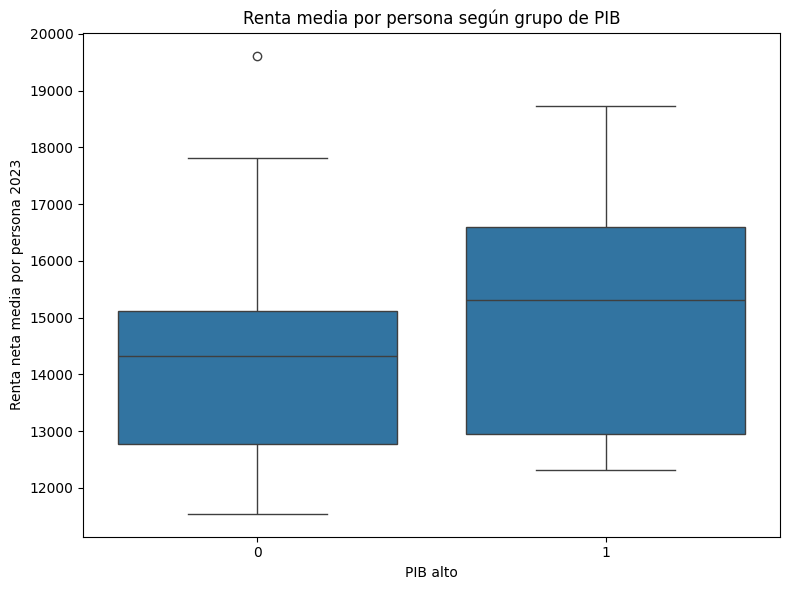

In [65]:
# Boxplots por grupo PIB alto
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_model,
    x="PIB_alto",
    y="Renta_neta_media_persona_2023"
)

plt.title("Renta media por persona según grupo de PIB")
plt.xlabel("PIB alto")
plt.ylabel("Renta neta media por persona 2023")
plt.tight_layout()
plt.show()

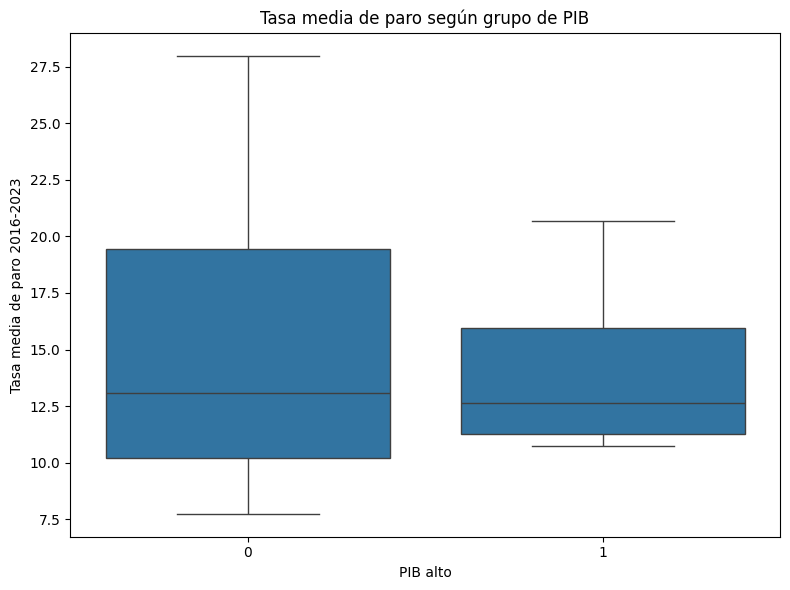

In [66]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_model,
    x="PIB_alto",
    y="paro_media_2016_2023"
)

plt.title("Tasa media de paro según grupo de PIB")
plt.xlabel("PIB alto")
plt.ylabel("Tasa media de paro 2016-2023")
plt.tight_layout()
plt.show()

El análisis de renta y mercado laboral muestra que las provincias clasificadas como de PIB alto presentan, en promedio, mejores indicadores que el resto. Su renta neta media por persona y por hogar es superior, mientras que la tasa media de paro es algo menor. También presentan tasas medias de empleo y actividad más elevadas.

Sin embargo, las diferencias no son tan marcadas como en variables como población, número de empresas o PIB total. El ranking de renta por persona muestra que algunas provincias con elevada renta media, como Gipuzkoa, Araba/Álava o Navarra, no necesariamente pertenecen al grupo de PIB alto. Esto indica que el PIB total y la renta media miden dimensiones distintas: el PIB refleja el tamaño económico agregado de la provincia, mientras que la renta media aproxima mejor el nivel económico de sus habitantes.

Los gráficos de dispersión y los boxplots refuerzan esta idea. Existe cierta relación positiva entre renta y PIB, pero con bastante dispersión. En el caso del paro, las provincias de PIB alto tienden a presentar valores algo menores, aunque también existe solapamiento con el resto de provincias. Por tanto, el PIB alto suele estar asociado a mejores indicadores laborales y de renta, pero no de forma automática ni uniforme.